Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

Load Dataset

In [2]:
df = pd.read_csv("/content/customer_churn_dataset-training-master.csv")

df.columns = df.columns.str.strip()

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (440833, 12)
   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0  Female    39.0             14.0            5.0   
1         3.0  65.0  Female    49.0              1.0           10.0   
2         4.0  55.0  Female    14.0              4.0            6.0   
3         5.0  58.0    Male    38.0             21.0            7.0   
4         6.0  23.0    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           18.0          Standard          Annual        932.0   
1            8.0             Basic         Monthly        557.0   
2           18.0             Basic       Quarterly        185.0   
3            7.0          Standard         Monthly        396.0   
4            8.0             Basic         Monthly        617.0   

   Last Interaction  Churn  
0              17.0    1.0  
1               6.0    1.0  
2               3.0    1.0  
3              29.0    1.0

Remove duplicates

In [3]:
df = df.drop_duplicates()

Encode categorical features

In [4]:
label_cols = ["Gender", "Subscription Type"]

for col in label_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = LabelEncoder().fit_transform(df[col])

Convert churn into Numeric

In [6]:
df.dropna(subset=['Churn'], inplace=True)
df["Churn"] = df["Churn"].astype(int)

print(df["Churn"].value_counts())

Churn
1    249999
0    190833
Name: count, dtype: int64


In [7]:
X = df.drop(["CustomerID","Churn"], axis=1)
y = df["Churn"]

Split into train and test

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

Feature Scaling

In [10]:
scaler = StandardScaler()

le_contract = LabelEncoder()
X_train.loc[:, 'Contract Length'] = le_contract.fit_transform(X_train['Contract Length'])
X_test.loc[:, 'Contract Length'] = le_contract.transform(X_test['Contract Length'])

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Models

In [11]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=250, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Naive Bayes": GaussianNB()
}

Model Training and Evaluation

In [12]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC AUC": roc_auc_score(y_test, prob)
    }

results_df = pd.DataFrame(results).T
print("\nMODEL PERFORMANCE")
print(results_df)


MODEL PERFORMANCE
                     Accuracy  Precision   Recall  F1 Score   ROC AUC
Logistic Regression  0.851044   0.878659  0.85548  0.866915  0.928081
Random Forest        0.999830   0.999940  0.99976  0.999850  0.999999
Gradient Boosting    0.996722   0.999940  0.99428  0.997102  0.999878
Naive Bayes          0.908741   0.949726  0.88598  0.916746  0.966542


Visualization of Model Evaluation

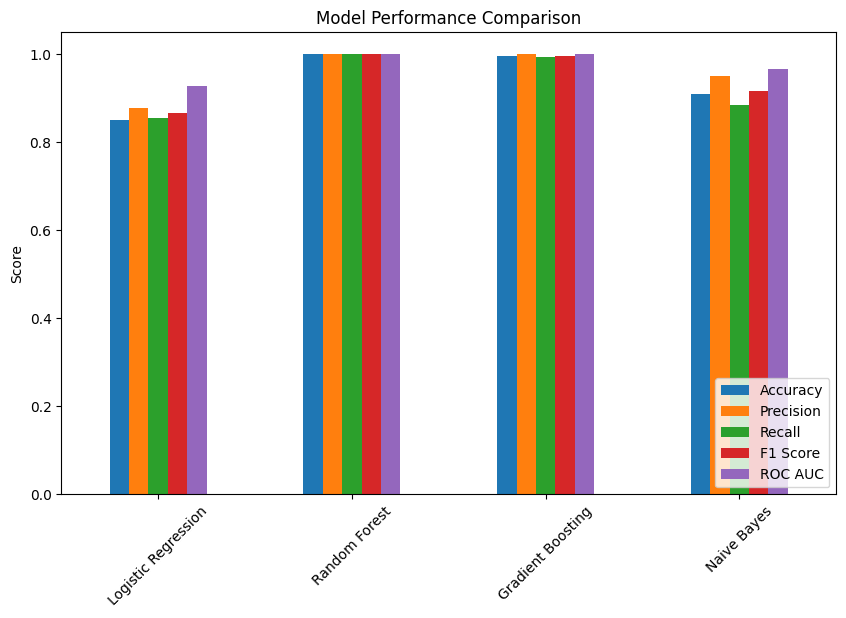

In [44]:
results_df.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.show()

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=250, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=250, random_state=42)

Save the model

In [15]:
import joblib

joblib.dump(rf, "churn_random_forest_model.pkl")

print("Model saved as churn_random_forest_model.pkl")

Model saved as churn_random_forest_model.pkl


Save the scaler

In [21]:
import joblib

joblib.dump(scaler, "churn_scaler.pkl")
print("Scaler saved")

Scaler saved


Load the Model

In [16]:
loaded_model = joblib.load("churn_random_forest_model.pkl")
print("Model loaded successfully")

Model loaded successfully


Confusion Matrix

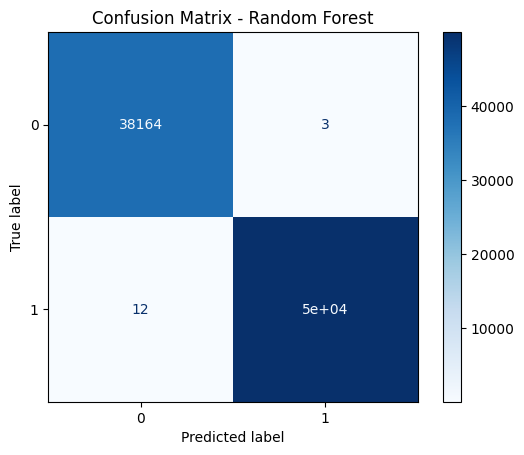

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

Visualization of Feature Importance

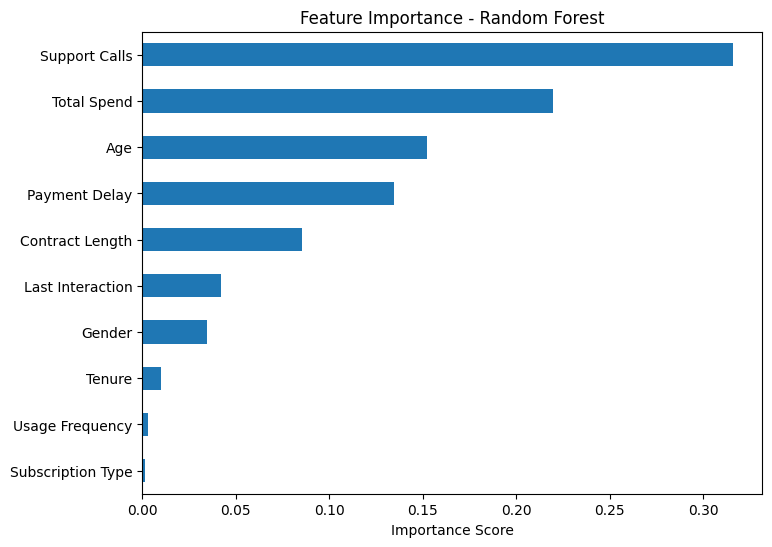

In [46]:
import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8,6))
feature_importance.plot(kind='barh')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()

Visualization of Churn Distribution

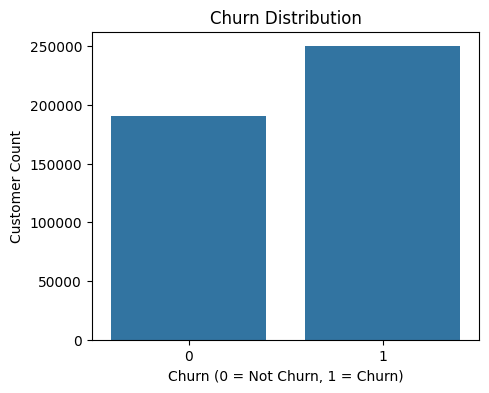

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = Not Churn, 1 = Churn)")
plt.ylabel("Customer Count")
plt.show()

Visualization of Churn Probability Distribution

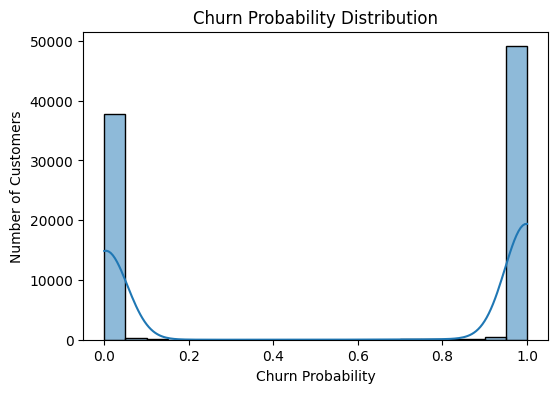

In [52]:
y_prob = rf.predict_proba(X_test)[:,1]

plt.figure(figsize=(6,4))
sns.histplot(y_prob, bins=20, kde=True)
plt.title("Churn Probability Distribution")
plt.xlabel("Churn Probability")
plt.ylabel("Number of Customers")
plt.show()

Model Prediction

In [20]:
sample = X.iloc[0:1].copy()
sample.loc[:, 'Contract Length'] = le_contract.transform(sample['Contract Length'])
sample_scaled = scaler.transform(sample)

prob = rf.predict_proba(sample_scaled)[0][1]
print("\nChurn Probability for sample:", round(prob,3))


Churn Probability for sample: 1.0


In [28]:
import pandas as pd
import joblib

# LOAD MODEL & SCALER
model = joblib.load("churn_random_forest_model.pkl")
scaler = joblib.load("churn_scaler.pkl")

# ENTER NEW CUSTOMER DATA
# Make sure order matches your features
new_customer = pd.DataFrame([{
    "Age": 27,
    "Gender": "Female",
    "Tenure": 9,
    "Usage Frequency": 13,
    "Support Calls": 3,
    "Payment Delay": 14,
    "Subscription Type": "Standard",
    "Contract Length": 12,
    "Total Spend": 294.62,
    "Last Interaction": 18
}])

# ENCODE CATEGORICAL COLUMNS
gender_map = {"male":0, "female":1}
subscription_map = {
    "basic":0,
    "standard":1,
    "premium":2
}

new_customer["Gender"] = new_customer["Gender"].str.lower().map(gender_map)
new_customer["Subscription Type"] = new_customer["Subscription Type"].str.lower().map(subscription_map)

# SCALE NUMERIC DATA
scaled_input = scaler.transform(new_customer)

# PREDICT
prediction = model.predict(scaled_input)[0]
probability = model.predict_proba(scaled_input)[0][1]

print("Prediction:", prediction)
print("Churn Probability:", round(probability,3))

if prediction == 1:
    print("Customer is likely to CHURN")
else:
    print("Customer is NOT likely to churn")

Prediction: 1
Churn Probability: 1.0
Customer is likely to CHURN


In [43]:
import pandas as pd
import joblib

# LOAD MODEL & SCALER
model = joblib.load("churn_random_forest_model.pkl")
scaler = joblib.load("churn_scaler.pkl")

# ENTER NEW CUSTOMER DATA
# Make sure order matches your features
new_customer = pd.DataFrame([{
    "Age": 26,
    "Gender": "Male",
    "Tenure": 4,               # Very short tenure
    "Usage Frequency": 2,      # Low usage
    "Support Calls": 7,        # Many complaints
    "Payment Delay": 28,       # Frequent late payments
    "Subscription Type": "Basic",
    "Contract Length": 1,      # Monthly contract
    "Total Spend": 180.50,     # Low spending
    "Last Interaction": 45
}])

# ENCODE CATEGORICAL COLUMNS
gender_map = {"male":0, "female":1}
subscription_map = {
    "basic":0,
    "standard":1,
    "premium":2
}

new_customer["Gender"] = new_customer["Gender"].str.lower().map(gender_map)
new_customer["Subscription Type"] = new_customer["Subscription Type"].str.lower().map(subscription_map)

# SCALE NUMERIC DATA
scaled_input = scaler.transform(new_customer)

# PREDICT
prediction = model.predict(scaled_input)[0]
probability = model.predict_proba(scaled_input)[0][1]

print("Prediction:", prediction)
print("Churn Probability:", round(probability,3))

if prediction == 1:
    print("Customer is likely to CHURN")
else:
    print("Customer is NOT likely to churn")

Prediction: 1
Churn Probability: 1.0
Customer is likely to CHURN


In [36]:
import pandas as pd
import joblib

# LOAD MODEL & SCALER
model = joblib.load("churn_random_forest_model.pkl")
scaler = joblib.load("churn_scaler.pkl")

# ENTER NEW CUSTOMER DATA
# Make sure order matches your features
new_customer = pd.DataFrame([{
    "Age": 30,
    "Gender": "Female",
    "Tenure": 24,
    "Usage Frequency": 10,
    "Support Calls": 2,
    "Payment Delay": 5,
    "Subscription Type": "Standard",
    "Contract Length": 12,
    "Total Spend": 2500,
    "Last Interaction": 7
}])

# ENCODE CATEGORICAL COLUMNS
gender_map = {"male":0, "female":1}
subscription_map = {
    "basic":0,
    "standard":1,
    "premium":2
}

new_customer["Gender"] = new_customer["Gender"].str.lower().map(gender_map)
new_customer["Subscription Type"] = new_customer["Subscription Type"].str.lower().map(subscription_map)

# SCALE NUMERIC DATA
scaled_input = scaler.transform(new_customer)

# PREDICT
prediction = model.predict(scaled_input)[0]
probability = model.predict_proba(scaled_input)[0][1]

print("Prediction:", prediction)
print("Churn Probability:", round(probability,3))

if prediction == 1:
    print("Customer is likely to CHURN")
else:
    print("Customer is NOT likely to churn")

Prediction: 0
Churn Probability: 0.172
Customer is NOT likely to churn


In [38]:
import pandas as pd
import joblib

# LOAD MODEL & SCALER
model = joblib.load("churn_random_forest_model.pkl")
scaler = joblib.load("churn_scaler.pkl")

# ENTER NEW CUSTOMER DATA
# Make sure order matches your features
new_customer = pd.DataFrame([{
    "Age": 35,
    "Gender": "Female",
    "Tenure": 48,              # Long relationship
    "Usage Frequency": 20,     # High usage
    "Support Calls": 0,        # No issues
    "Payment Delay": 0,        # On-time payments
    "Subscription Type": "Premium",
    "Contract Length": 12,     # Annual contract
    "Total Spend": 5200.00,    # High lifetime value
    "Last Interaction": 3
}])

# ENCODE CATEGORICAL COLUMNS
gender_map = {"male":0, "female":1}
subscription_map = {
    "basic":0,
    "standard":1,
    "premium":2
}

new_customer["Gender"] = new_customer["Gender"].str.lower().map(gender_map)
new_customer["Subscription Type"] = new_customer["Subscription Type"].str.lower().map(subscription_map)

# SCALE NUMERIC DATA
scaled_input = scaler.transform(new_customer)

# PREDICT
prediction = model.predict(scaled_input)[0]
probability = model.predict_proba(scaled_input)[0][1]

print("Prediction:", prediction)
print("Churn Probability:", round(probability,3))

if prediction == 1:
    print("Customer is likely to CHURN")
else:
    print("Customer is NOT likely to churn")

Prediction: 0
Churn Probability: 0.248
Customer is NOT likely to churn


In [47]:
import pandas as pd
import joblib

# LOAD MODEL & SCALER
model = joblib.load("churn_random_forest_model.pkl")
scaler = joblib.load("churn_scaler.pkl")

# NEW CUSTOMER INPUT
new_customer = pd.DataFrame([{
    "Age": 35,
    "Gender": "Female",
    "Tenure": 48,
    "Usage Frequency": 20,
    "Support Calls": 0,
    "Payment Delay": 0,
    "Subscription Type": "Premium",
    "Contract Length": 12,
    "Total Spend": 5200.00,
    "Last Interaction": 3
}])

# ENCODE CATEGORICAL FEATURES
gender_map = {"male": 0, "female": 1}
subscription_map = {
    "basic": 0,
    "standard": 1,
    "premium": 2
}

new_customer["Gender"] = new_customer["Gender"].str.lower().map(gender_map)
new_customer["Subscription Type"] = new_customer["Subscription Type"].str.lower().map(subscription_map)

# SCALE INPUT
scaled_input = scaler.transform(new_customer)

# PREDICT
prediction = model.predict(scaled_input)[0]
probability = model.predict_proba(scaled_input)[0][1]

# RISK CLASSIFICATION
risk_percentage = round(probability * 100, 2)

print("Churn Prediction:", prediction)
print(f"Churn Probability: {risk_percentage}%")

if probability >= 0.70:
    print("Risk Level: HIGH RISK")
    print("Action: Immediate retention strategy required")
elif probability >= 0.40:
    print("Risk Level: MEDIUM RISK")
    print("Action: Monitor and engage customer")
else:
    print("Risk Level: LOW RISK")
    print("Action: Customer is likely to stay")

Churn Prediction: 0
Churn Probability: 24.8%
Risk Level: LOW RISK
Action: Customer is likely to stay


In [50]:
import pandas as pd
import joblib

# LOAD MODEL & SCALER
model = joblib.load("churn_random_forest_model.pkl")
scaler = joblib.load("churn_scaler.pkl")

# NEW CUSTOMER INPUT
new_customer = pd.DataFrame([{
    "Age": 24,
    "Gender": "Male",
    "Tenure": 2,
    "Usage Frequency": 1,
    "Support Calls": 8,
    "Payment Delay": 30,
    "Subscription Type": "Basic",
    "Contract Length": 1,
    "Total Spend": 120,
    "Last Interaction": 50
}])

# ENCODE CATEGORICAL FEATURES
gender_map = {"male": 0, "female": 1}
subscription_map = {
    "basic": 0,
    "standard": 1,
    "premium": 2
}

new_customer["Gender"] = new_customer["Gender"].str.lower().map(gender_map)
new_customer["Subscription Type"] = new_customer["Subscription Type"].str.lower().map(subscription_map)

# SCALE INPUT
scaled_input = scaler.transform(new_customer)

# PREDICT
prediction = model.predict(scaled_input)[0]
probability = model.predict_proba(scaled_input)[0][1]

# RISK CLASSIFICATION
risk_percentage = round(probability * 100, 2)

print("Churn Prediction:", prediction)
print(f"Churn Probability: {risk_percentage}%")
if prediction == 1:
    print("Prediction: CHURN")
else:
    print("Prediction: NOT CHURN")

print(f"Churn Probability: {risk_percentage}%")

if probability >= 0.70:
    print("Risk Level: HIGH RISK")
    print("Action: Immediate retention strategy required")
elif probability >= 0.40:
    print("Risk Level: MEDIUM RISK")
    print("Action: Monitor and engage customer")
else:
    print("Risk Level: LOW RISK")
    print("Action: Customer is likely to stay")

Churn Prediction: 1
Churn Probability: 100.0%
Prediction: CHURN
Churn Probability: 100.0%
Risk Level: HIGH RISK
Action: Immediate retention strategy required


In [42]:
import pandas as pd
import joblib

# LOAD MODEL & SCALER
model = joblib.load("churn_random_forest_model.pkl")
scaler = joblib.load("churn_scaler.pkl")

# ENTER NEW CUSTOMER DATA
# Make sure order matches your features
new_customer = pd.DataFrame([{
    "Age": 43,
    "Gender": "Male",
    "Tenure": 38,      # Number of months the customer has been with the company
    "Usage Frequency": 14, # Frequency of customer uses the service
    "Support Calls": 1, # Total number of times customer contacted customer support
    "Payment Delay": 12, # Number of days the customer delayed payment on average
    "Subscription Type": "Standard",   # Type of subscription plan
    "Contract Length": 3,     # Length of the contract in months
    "Total Spend": 682.14,   # Total amount spend
    "Last Interaction": 6   # Number of days since the customer interact

}])

# ENCODE CATEGORICAL COLUMNS
gender_map = {"male":0, "female":1}
subscription_map = {
    "basic":0,
    "standard":1,
    "premium":2
}

new_customer["Gender"] = new_customer["Gender"].str.lower().map(gender_map)
new_customer["Subscription Type"] = new_customer["Subscription Type"].str.lower().map(subscription_map)

# SCALE NUMERIC DATA
scaled_input = scaler.transform(new_customer)

# PREDICT
prediction = model.predict(scaled_input)[0]
probability = model.predict_proba(scaled_input)[0][1]

print("Prediction:", prediction)
print("Churn Probability:", round(probability,3))

if prediction == 1:
    print("Customer is likely to CHURN")
else:
    print("Customer is NOT likely to churn")

Prediction: 0
Churn Probability: 0.0
Customer is NOT likely to churn
